## Part 1 – Get to Know the Prediction Problem

**1. Load the dataset and examine its structure.**
- Load the CSV file into pandas.
- Display the first 5 rows.
- Report the number of rows and columns.
- Print the column names.
- Use info() to inspect the dataset.

Answer:
- Which variable will be the target?
- Which columns appear to be numerical?
- Which columns appear to be categorical?

Target = past_due_rent

Numerical columns appear to be adults_in_household, children_in_household, monthly_household_income, and monthly_rent

Categorical columns appear to be household_has_65plus, income_sources, employment_status, has_housing_voucher, eviction_in_progress, behind_on_utilities, main_reason_behind_on_rent, intake_quarter

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SLCM_rent_arrears_student_clean.csv")
display(df.head())
print(df.shape)
print(df.columns.tolist())
df.info()

,record_id,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent,past_due_rent
0,SLCM_0001,1,1,No,293.0,"Food benefits - TANF/SNAP, No income, Other",Unemployed but want to find work,No,I don't know,Yes,Other,2026-Q1,1560.0,3100.0
1,SLCM_0002,0,3,No,2000.0,Child support,Employed,No,I don't know,Yes,Unexpected expense,2026-Q3,1550.0,7300.0
2,SLCM_0003,1,0,No,400.0,Food benefits - TANF/SNAP,Unemployed but want to find work,I don't know,Yes,Yes,Lost a job/had hours cut,2025-Q4,0.0,6000.0
3,SLCM_0004,2,0,No,2500.0,Full-time employment,Unemployed and not looking for work,No,Yes,Yes,Lost a job/had hours cut,2026-Q2,1299.0,2500.0
4,SLCM_0005,1,2,No,14.0,Part-time employment,Employed,No,Yes,No,Unexpected expense,2025-Q4,1105.5,1205.5


(1754, 14)
['record_id', 'adults_in_household', 'children_in_household', 'household_has_65plus', 'monthly_household_income', 'income_sources', 'employment_status', 'has_housing_voucher', 'eviction_in_progress', 'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter', 'monthly_rent', 'past_due_rent']
<class 'pandas.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   1754 non-null   str    
 1   adults_in_household         1754 non-null   int64  
 2   children_in_household       1754 non-null   int64  
 3   household_has_65plus        1754 non-null   str    
 4   monthly_household_income    1646 non-null   float64
 5   income_sources              1754 non-null   str    
 6   employment_status           1754 non-null   str    
 7   has_housing_voucher         1754 non-null   str    
 8   eviction_in_pr

In [3]:
missing = df.isnull().sum()
print(missing)
print(missing[missing > 0])
print((missing[missing > 0] / len(df) * 100).round(2))

record_id                       0
adults_in_household             0
children_in_household           0
household_has_65plus            0
monthly_household_income      108
income_sources                  0
employment_status               0
has_housing_voucher             0
eviction_in_progress            1
behind_on_utilities             7
main_reason_behind_on_rent     16
intake_quarter                  0
monthly_rent                    8
past_due_rent                   0
dtype: int64
monthly_household_income      108
eviction_in_progress            1
behind_on_utilities             7
main_reason_behind_on_rent     16
monthly_rent                    8
dtype: int64
monthly_household_income      6.16
eviction_in_progress          0.06
behind_on_utilities           0.40
main_reason_behind_on_rent    0.91
monthly_rent                  0.46
dtype: float64


**2. Investigate missing values.**
- Calculate the number of missing values in every column.
- Identify which variables contain missing data.
- Briefly describe how you plan to handle those missing values before modeling.

Do not simply remove all rows with missing data unless you can justify that decision.

monthly_household_rent = 108
main_reason_behind_on_rent = 16
behind_on_utilities = 7
monthly_rent = 8
eviction_in_progress = 1

I plan on filling the numeric gaps with a median. The median wont be pulled up by a few huge values which matters for the mon ey column. I will fill the categorical gaps with the most frequent value. I do not want to drop rows because income alone would cost near 6% of th dataset. Everything else is 1%


In [4]:
target = df["past_due_rent"]

print(target.describe())
print("median:", target.median())

count     1754.000000
mean      2408.006933
std       2089.515372
min          0.000000
25%       1050.000000
50%       2000.000000
75%       3200.000000
max      20000.000000
Name: past_due_rent, dtype: float64
median: 2000.0


/tmp/ipykernel_3134/3006009031.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


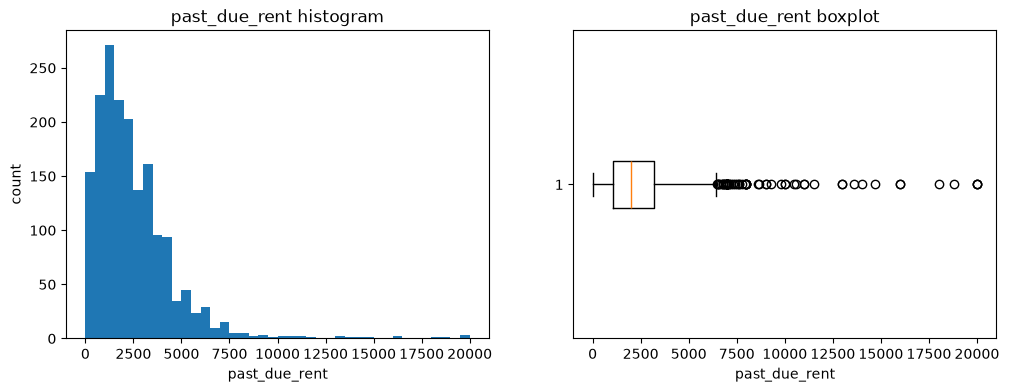

In [5]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    target,
    bins=40
)
axes[0].set_title("past_due_rent histogram")
axes[0].set_xlabel("past_due_rent")
axes[0].set_ylabel("count")

axes[1].boxplot(
    target,
    vert=False
)
axes[1].set_title("past_due_rent boxplot")
axes[1].set_xlabel("past_due_rent")

plt.show()

**3. Explore the target variable: past_due_rent.**

Calculate:
- count
- mean
- median
- standard deviation
- minimum
- maximum

Create:
- a histogram
- a boxplot

Answer:
- What does the distribution look like? 
- Is the distribution symmetric or skewed?
- Are the mean and median similar?
- Do you notice any unusually high values?
- Why might rent-arrears data naturally contain a wide range of values?

Do not automatically remove an observation simply because it is high.

The distribution is right skwered with most households owing between $0 to $4,000. The mean is about $2,408 and the median is $2,000. The mean is higher because there are alrger values that pull it up. There is a small cluster right at $20,000. The reason there a wide range of values is the different situations everyone is in. Some people could be one month behind while other are like a year behind.

In [6]:
x = df.drop(columns=["past_due_rent", "record_id"])
y = df["past_due_rent"]
print(x.shape, y.shape)

(1754, 12) (1754,)


In [7]:
num_cols = [
    "adults_in_household",
    "children_in_household",
    "monthly_household_income",
    "monthly_rent"
]

cat_cols = [
    "household_has_65plus",
    "income_sources",
    "employment_status",
    "has_housing_voucher",
    "eviction_in_progress",
    "behind_on_utilities",
    "main_reason_behind_on_rent",
    "intake_quarter"
]

print("numerical:", num_cols)
print("categorical:", cat_cols)

numerical: ['adults_in_household', 'children_in_household', 'monthly_household_income', 'monthly_rent']
categorical: ['household_has_65plus', 'income_sources', 'employment_status', 'has_housing_voucher', 'eviction_in_progress', 'behind_on_utilities', 'main_reason_behind_on_rent', 'intake_quarter']


In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (1403, 12)
x_test: (351, 12)
y_train: (1403,)
y_test: (351,)


## Part 2 – Prepare the Data for Machine Learning

**4. Create your input features and target.**

Create X and y using past_due_rent as the target. Do not use record_id as an input feature.

Answer:
- Why should record_id not be used to predict past-due rent? - Record_id looks to just be a label and his no relationship to rent. Any pattern found would not actually be a pattern and more of a coincidence

**5. Separate the numerical and categorical features.**
- Create lists containing numerical features and categorical features.
- Display both lists.
- Briefly explain why machine-learning models require different preparation steps for numerical and categorical variables. - The categorical variables need to be converted into numbers while numeric columns need scaling. This is the case because models only really do math

**6. Split the data into training and testing sets.**

Use test_size=0.20 and random_state=42.
- Report the dimensions of X_train, X_test, y_train, and y_test.
- Why should the model be evaluated using data that was not used during training?

Training set has 1403 households and the test set has 351, each with 12 features. Testing on unseen data show how the model will handle new households.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [10]:
from sklearn.preprocessing import OneHotEncoder

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

cat_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto acc

In [11]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

**7. Prepare the numerical variables.**

Create an appropriate numerical preprocessing pipeline. Your pipeline should consider missing values and feature scaling. Use appropriate tools such as SimpleImputer and StandardScaler.

Explain:
- How did you handle missing numerical values? - median imputation which suits skewed income and rent. It also matters that it is not thrown off by extreme values.
- Why might feature scaling matter when comparing Linear, Ridge, and Lasso models? - Scaling matters because Ridge and Lasso penalize coeffcient size. Incomes would get penalized unevenly just because of their units without it



**8. Prepare the categorical variables.**

Create an appropriate categorical preprocessing pipeline. Your pipeline should consider missing values and converting text categories into numerical values. Use appropriate tools such as SimpleImputer and OneHotEncoder.

Answer:
- Why can the regression models not directly use values such as employment categories? - because regression needs numbers and something like "employed" is not a number
- Why is one-hot encoding appropriate for these variables? - to have no order implied each category will get its own 0/1
- Why would assigning arbitrary numbers such as 1, 2, 3, and 4 to unordered categories potentially be misleading? - The model will treat it as if it was ranked which would make it meaningless

**9. Combine your preprocessing steps.**

- Explain briefly why using a preprocessing pipeline is useful. - Same steps get applied to training, test, and new data automatically.

## Part 3 – Build and Compare Regression Models

**10. Build a Multiple Linear Regression model.**

Create a pipeline containing your preprocessing and a Linear Regression model. Train the model using the training data and make predictions for the testing data.

Calculate:
- RMSE
- R²

Create an Actual vs. Predicted scatterplot with actual values on the x-axis, predicted values on the y-axis, and a diagonal reference line showing where perfect predictions would fall.

Answer:
- What does RMSE represent in this problem? - RSME = $1,861 predictions are usually off about $1,861 miss the actual past due rent.
- What does the R² score tell you? - R² score tells us that the moddel accounts for about 15.5% of households differ in past due rent.
- Based on the graph, how closely do the predictions match the actual values? - It seems the predictions are all between about $0 and $5,500 even though actual values go up to $20,000 so it is close only for households owing $1,000 to $4,000
- Do you notice cases where the model makes large prediction errors? - Yes there are areas where households are under and over predicted. The $20,000 households is predicted at $2,000 and $0 predicted at $2,000 - $3,700

In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(x_train, y_train)
linear_preds = linear_model.predict(x_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_r2 = r2_score(y_test, linear_preds)

print("rmse:", round(linear_rmse, 2))
print("r2:", round(linear_r2, 4))

rmse: 1861.21
r2: 0.1549


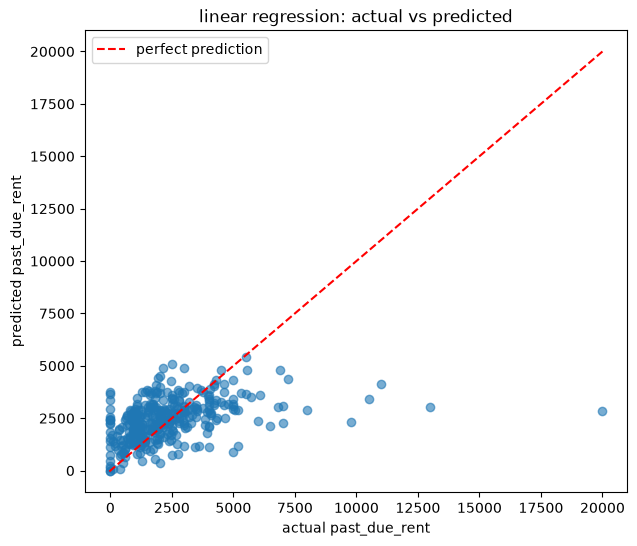

In [14]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    linear_preds,
    alpha=0.6
)

low = min(y_test.min(), linear_preds.min())
high = max(y_test.max(), linear_preds.max())

plt.plot(
    [low, high],
    [low, high],
    "r--",
    label="perfect prediction"
)

plt.xlabel("actual past_due_rent")
plt.ylabel("predicted past_due_rent")
plt.title("linear regression: actual vs predicted")
plt.legend()
plt.show()

**11. Build a Polynomial Regression model.**

Real-world relationships are not always perfectly linear. For this model, use PolynomialFeatures(degree=2, include_bias=False). Apply polynomial transformation to the appropriate numerical variables. Do not automatically apply polynomial expansion to all one-hot encoded categorical variables.

Train the model and calculate RMSE and R².

Answer:
- Did Polynomial Regression perform better or worse than Linear Regression? Polynomial did slightly worse than Linera Regression. RMSE went up to $1,875 and R² went down to .142
- What does a degree-2 polynomial allow the model to represent that Linear Regression cannot? - Instead of straight line effects, degree-2 polynomial allows for curved relationships
- Why could using a very high polynomial degree lead to overfitting? - It would create a lot of extra terms so the model can fit odd cases in it. This would eventually lead to it doing worse on new data.
- Did making the model more complicated automatically make it better? - The added complexity just made more terms without improving it.

In [15]:
from sklearn.preprocessing import PolynomialFeatures

poly_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

poly_preprocessor = ColumnTransformer([
    ("num", poly_num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

poly_model = Pipeline([
    ("prep", poly_preprocessor),
    ("model", LinearRegression())
])

poly_model.fit(x_train, y_train)
poly_preds = poly_model.predict(x_test)

poly_rmse = np.sqrt(mean_squared_error(y_test, poly_preds))
poly_r2 = r2_score(y_test, poly_preds)

print("rmse:", round(poly_rmse, 2))
print("r2:", round(poly_r2, 4))

rmse: 1875.02
r2: 0.1423


**12. Build a Ridge Regression model.**

Create a Ridge Regression pipeline using the same training and testing data. Choose a reasonable value for alpha. You may experiment with more than one value.

Calculate RMSE and R².

Answer:
- How does Ridge Regression compare with Linear Regression? - It was better but not by a lot. Having alpha = 100, RMSE was equal to $1,837. R² then went up to .176. Anything pass 100 seem to make it worse 
- What does regularization do? - Penalizes large coefficients which shrinks them toward zero. This makes it so the model cannot lean heavily on just one feature
- Why can regularization be useful when a model contains many features? -  Regularization and shrinking the coefficients will keep the model more stabel on new data while one hot encoding will create a lot of columns which could make the model overfit.


In [16]:
from sklearn.linear_model import Ridge

for a in [0.1, 1, 10, 50, 100]:
    test_model = Pipeline([
        ("prep", preprocessor),
        ("model", Ridge(alpha=a))
    ])
    test_model.fit(x_train, y_train)
    p = test_model.predict(x_test)
    print(
        "alpha:", a,
        "rmse:", round(np.sqrt(mean_squared_error(y_test, p)), 2),
        "r2:", round(r2_score(y_test, p), 4)
    )

alpha: 0.1 rmse: 1858.9 r2: 0.157
alpha: 1 rmse: 1849.18 r2: 0.1658
alpha: 10 rmse: 1840.57 r2: 0.1736
alpha: 50 rmse: 1838.17 r2: 0.1757
alpha: 100 rmse: 1837.41 r2: 0.1764


In [17]:
for a in [100, 200, 500, 1000]:
    test_model = Pipeline([
        ("prep", preprocessor),
        ("model", Ridge(alpha=a))
    ])
    test_model.fit(x_train, y_train)
    p = test_model.predict(x_test)
    print(
        "alpha:", a,
        "rmse:", round(np.sqrt(mean_squared_error(y_test, p)), 2),
        "r2:", round(r2_score(y_test, p), 4)
    )

alpha: 100 rmse: 1837.41 r2: 0.1764
alpha: 200 rmse: 1839.42 r2: 0.1746
alpha: 500 rmse: 1852.17 r2: 0.1631
alpha: 1000 rmse: 1873.43 r2: 0.1438


In [18]:
ridge_model = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(alpha=100))
])

ridge_model.fit(x_train, y_train)
ridge_preds = ridge_model.predict(x_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_r2 = r2_score(y_test, ridge_preds)

print("rmse:", round(ridge_rmse, 2))
print("r2:", round(ridge_r2, 4))

rmse: 1837.41
r2: 0.1764


**13. Build a Lasso Regression model.**

Create a Lasso Regression pipeline using the same training and testing data. Choose a reasonable value for alpha.

Calculate RMSE and R².

Answer:
- How does Lasso compare with Linear and Ridge Regression? -  Lasso does the best out of the other 2. At alpha = 10, RSME was $1826 and R² was .186
- What is an important difference between Ridge and Lasso? - Ridge shrinks coefficients towards zero but keeps them. Lasso shrinks them to exactly zero which would remove those features.
- What can happen to some coefficients when Lasso is used? - The became exactly 0. With alpha being at 10, out of 116 coefficients 87 were zeroed out.

In [19]:
from sklearn.linear_model import Lasso

for a in [1, 10, 50, 100, 200]:
    test_model = Pipeline([
        ("prep", preprocessor),
        ("model", Lasso(alpha=a, max_iter=10000))
    ])
    test_model.fit(x_train, y_train)
    p = test_model.predict(x_test)
    coefs = test_model.named_steps["model"].coef_
    print(
        "alpha:", a,
        "rmse:", round(np.sqrt(mean_squared_error(y_test, p)), 2),
        "r2:", round(r2_score(y_test, p), 4),
        "zero coefs:", np.sum(coefs == 0), "of", len(coefs)
    )

alpha: 1 rmse: 1841.89 r2: 0.1724 zero coefs: 36 of 116
alpha: 10 rmse: 1826.44 r2: 0.1862 zero coefs: 87 of 116
alpha: 50 rmse: 1839.01 r2: 0.1749 zero coefs: 107 of 116
alpha: 100 rmse: 1865.15 r2: 0.1513 zero coefs: 112 of 116
alpha: 200 rmse: 1914.96 r2: 0.1054 zero coefs: 115 of 116


In [20]:
lasso_model = Pipeline([
    ("prep", preprocessor),
    ("model", Lasso(alpha=10, max_iter=10000))
])

lasso_model.fit(x_train, y_train)
lasso_preds = lasso_model.predict(x_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_preds))
lasso_r2 = r2_score(y_test, lasso_preds)

print("rmse:", round(lasso_rmse, 2))
print("r2:", round(lasso_r2, 4))

rmse: 1826.44
r2: 0.1862


In [21]:
feature_names = lasso_model.named_steps["prep"].get_feature_names_out()
coefs = lasso_model.named_steps["model"].coef_

kept = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
})
kept = kept[kept["coef"] != 0].sort_values(
    "coef",
    key=abs,
    ascending=False
)

print("kept", len(kept), "of", len(coefs))
display(kept)

kept 29 of 116


,feature,coef
31,"cat__income_sources_Full-time employment, Other",8.140940e+02
96,cat__eviction_in_progress_I don't know,-7.643416e+02
3,num__monthly_rent,5.641175e+02
109,cat__intake_quarter_2025-Q1,4.391302e+02
39,"cat__income_sources_Full-time employment, Soci...",3.936160e+02
88,cat__employment_status_Employed,3.748526e+02
95,cat__has_housing_voucher_Yes,-2.233414e+02
103,cat__main_reason_behind_on_rent_Lost a job/had...,2.119787e+02
110,cat__intake_quarter_2025-Q2,2.026080e+02
113,cat__intake_quarter_2026-Q1,1.988380e+02


**14. Compare all four models.**

Create a DataFrame containing the test-set results for all four models.

Answer:
- Which model has the lowest RMSE? - Lasso with $1826
- Which model has the highest R²? - Lasso with .186
- Are the differences between the models large or small? - The difference was small with all the RMSEs and R² being relatively close to each other. 
- Did the most complicated model perform the best? - No polynomial did the worst while being the most complex.
- Which model would you continue investigating? Explain your choice using evidence from your results. - I will continue investigating Lasso because it had the lowest RMSE and highest R².

In [22]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "RMSE": [
        linear_rmse,
        poly_rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R²": [
        linear_r2,
        poly_r2,
        ridge_r2,
        lasso_r2
    ]
}).round(4)

display(results_df)

,Model,RMSE,R²
0,Linear Regression,1861.2128,0.1549
1,Polynomial Regression,1875.0169,0.1423
2,Ridge Regression,1837.4052,0.1764
3,Lasso Regression,1826.4430,0.1862


**15. Test your selected model on two hypothetical households.**

Create TWO new hypothetical cases. Do not copy an actual person from the dataset.

Change several characteristics between the two cases, such as:
- household size
- monthly household income
- employment status
- housing voucher status
- utility situation
- monthly rent

Use your selected pipeline to predict past_due_rent for both cases.

Then explain:
- How are the two households different? 
Household A: 1 adult with 6 kids, $862/month income, part-time income but currently unemployed, no voucher, behind on utilities, lost a job, $1,400 rent
Household B: 3 adults with 1 kid, $2,800/month, employed full-time, has a voucher, not behind on utilities, behind because of an unexpected expense, $1,200 rent.
- How different are the predictions? -  A is predicted to be about $3,128 and B is predicted to be about $2,816. This difference is about $321 even when the houses are dirastically drastically 
- Does the difference seem reasonable based on the information you provided? - It is kinda  reasonable as the higher need house is predicted to owe more but I believe the gap between them should be bigger. While it seems to add a positive wieght to employed and more adults, household size and income seem to have small weights.

In [23]:
for col in cat_cols:
    print(col, ":", x[col].unique()[:10])

household_has_65plus : <StringArray>
['No', 'Yes', 'Prefer not to answer']
Length: 3, dtype: str
income_sources : <StringArray>
[                                                              'Food benefits - TANF/SNAP, No income, Other',
                                                                                             'Child support',
                                                                                 'Food benefits - TANF/SNAP',
                                                                                      'Full-time employment',
                                                                                      'Part-time employment',
                                                                                                 'No income',
                                                                  'Child support, Food benefits - TANF/SNAP',
                                                                      'Food benefits - TANF/SNAP, No i

In [26]:
households = pd.DataFrame([
    {
        "adults_in_household": 1,
        "children_in_household": 6,
        "household_has_65plus": "No",
        "monthly_household_income": 862.0,
        "income_sources": "Part-time employment",
        "employment_status": "Unemployed but want to find work",
        "has_housing_voucher": "No",
        "eviction_in_progress": "No",
        "behind_on_utilities": "Yes",
        "main_reason_behind_on_rent": "Lost a job/had hours cut",
        "intake_quarter": "2026-Q3",
        "monthly_rent": 1400.0
    },
    {
        "adults_in_household": 3,
        "children_in_household": 1,
        "household_has_65plus": "No",
        "monthly_household_income": 2800.0,
        "income_sources": "Full-time employment",
        "employment_status": "Employed",
        "has_housing_voucher": "Yes",
        "eviction_in_progress": "No",
        "behind_on_utilities": "No",
        "main_reason_behind_on_rent": "Unexpected expense",
        "intake_quarter": "2026-Q3",
        "monthly_rent": 1200.0
    }
])

display(households)
print(lasso_model.predict(households).round(2))

,adults_in_household,children_in_household,household_has_65plus,monthly_household_income,income_sources,employment_status,has_housing_voucher,eviction_in_progress,behind_on_utilities,main_reason_behind_on_rent,intake_quarter,monthly_rent
0,1,6,No,862.0,Part-time employment,Unemployed but want to find work,No,No,Yes,Lost a job/had hours cut,2026-Q3,1400.0
1,3,1,No,2800.0,Full-time employment,Employed,Yes,No,No,Unexpected expense,2026-Q3,1200.0


[3127.75 2815.71]


In [25]:
print(x["children_in_household"].value_counts().sort_index())

children_in_household
0    815
1    371
2    317
3    167
4     56
5     19
6      9
Name: count, dtype: int64


## Part 4 – Interpret the Results

**16. What did your models tell you?**

Lasso performed the best on the test data with having RMSE $1,826 and R² 0.186 at alpha = 10. The predicted errors were about $1,800 per household. This is close to the $2,000 median. This shows that the errors are large relative to typical amounts owed. The Polynomial Regression did not provide a meaningful improvement. The polynomial ended with $1,875 vs $1,861. The extra curved and interaction terms caused it to be slightly worse than linear regression. Regularization did show to slightly improve the results with Ridge and Lasso both beating linear, even though they only beat linear by about $25-35. The model seems to be able to predict households within the $1,000 to $4,000 range that is shown from the scatterplot. The model seems to struggle with the high end households ($20,000) and the $0 cases. It would squeeze these towards the average. When testing the hypothetical households, two households that were very different only differed by about $312.

**17. What is your overall finding for SLCM?**


I was trying to predict how much past due rent a household has when it comes to SLCM. I used household size, income and income sources, employment, housing voucher, utilities, eviction status, reason for falling behind, monthly rent, and intake quarter. The model was somewhat successful. It was able to give a prediction, but it was typically off by about $1,800. It did explain less than 20% of the difference between households. The most important finding was the patterns from job loss and rent amount. These two had the clearest pattern, with voucher also showing a clear pattern. Even with these patterns, most of what decides how far behind someone gets is just not captured. The only way this model could be used for understanding community needs is to have it be a very rough picture of the area. It cannot be used for judging an individual household. An important limitation is that it misses households that are very far behind pretty badly. One thing to note is that these are all just patterns and are not causes.